In [47]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

This current XGBoost model and pre processing is set for a 90 minute horizon 
Horizon can be changed (extended or shortend) via the  ```PREDICTION_HORIZON_MINUTES ```

shokran 

In [40]:
df = pd.read_csv('./dataset_xgb.csv')

/tmp/ipykernel_5257/1621026637.py:1: DtypeWarning: Columns (0: Previous Time, 1: Updated Time, 2: Date, 3: Tags, 4: GI, 5: Food type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./dataset_xgb.csv')


In [41]:
df['Time'] = pd.to_datetime(df['Time'])
df = df.set_index('Time')

In [133]:
df.columns
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 265978 entries, 2020-11-02 18:09:00 to 2022-04-25 21:06:00
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Glucose                 38337 non-null   float64
 1   Scan Glucose (mmol/L)   10405 non-null   float64
 2   Rapid Insulin           1051 non-null    float64
 3   Carbohydrates           1605 non-null    float64
 4   Long Insulin            184 non-null     float64
 5   Strip Glucose (mmol/L)  51 non-null      float64
 6   Insulin (Meal)          280 non-null     float64
 7   Insulin (Correction)    257 non-null     float64
 8   Body weight (kg)        40 non-null      float64
 9   bpm                     265978 non-null  float64
 10  distance                265978 non-null  float64
 11  calories                265978 non-null  float64
 12  hour                    265978 non-null  float64
 13  hour_sin                265978 non-null  float64
 1

In [142]:
fillna = ['Rapid Insulin', 'Long Insulin', 'Insulin (Meal)', 'Insulin (Correction)', 'Carbohydrates', 'Strip Glucose (mmol/L)', 'cal_per_kg', 'dist_per_kg', 'Scan Glucose (mmol/L)']

df[fillna] = df[fillna].fillna(0, inplace=True)

/tmp/ipykernel_5257/3898170944.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[fillna] = df[fillna].fillna(0, inplace=True)


In [153]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 265978 entries, 2020-11-02 18:09:00 to 2022-04-25 21:06:00
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Glucose                 38337 non-null   float64
 1   Scan Glucose (mmol/L)   265978 non-null  float64
 2   Rapid Insulin           265978 non-null  float64
 3   Carbohydrates           265978 non-null  float64
 4   Long Insulin            265978 non-null  float64
 5   Strip Glucose (mmol/L)  265978 non-null  float64
 6   Insulin (Meal)          265978 non-null  float64
 7   Insulin (Correction)    265978 non-null  float64
 8   Body weight (kg)        265978 non-null  float64
 9   bpm                     265978 non-null  float64
 10  distance                265978 non-null  float64
 11  calories                265978 non-null  float64
 12  hour                    265978 non-null  float64
 13  hour_sin                265978 non-null  float64
 1

In [170]:
nas= ['bpm_lag_4', 'bpm_lag_3', 'bpm_lag_2', 'bpm_lag_1', 'bpm_roll_std']
df[nas] = df[nas].fillna(df[nas].mean(), inplace=True)

/tmp/ipykernel_5257/227538637.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[nas] = df[nas].fillna(df[nas].mean(), inplace=True)


In [144]:
df['glucose_lag1'] = df['Glucose'].shift(1)
df['glucose_lag2'] = df['Glucose'].shift(2)


In [ ]:
df = df.sort_index()

# Create a Series of last meal times
last_meal_time = pd.Series(df.index, index=df.index)
last_meal_time = last_meal_time.where(df['Carbohydrates'] > 0)  # NaT for non-meal rows



last_meal_time = last_meal_time.ffill()

df['hours_since_last_meal'] = (df.index - last_meal_time).dt.total_seconds() / 3600
df['hours_since_last_meal'] = df['hours_since_last_meal'].fillna(0)

In [129]:
df['GI'].value_counts()

GI
Medium        608
High          270
Very High     260
Low            82
Medium          7
1               3
2               2
 Very High      1
Very High       1
3               1
High            1
Name: count, dtype: int64

In [136]:
df['Body weight (kg)'] = df['Body weight (kg)'].fillna(df['Body weight (kg)'].mean(), inplace=True)

/tmp/ipykernel_5257/1049018092.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Body weight (kg)'] = df['Body weight (kg)'].fillna(df['Body weight (kg)'].mean(), inplace=True)


In [135]:
df['Body weight (kg)'] = df['Body weight (kg)'].ffill(inplace=True).bfill(inplace=True)

/tmp/ipykernel_5257/3813537877.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Body weight (kg)'] = df['Body weight (kg)'].ffill(inplace=True).bfill(inplace=True)


In [130]:
df.drop(columns=[  "Unnamed: 0",'Tags', 'Date', 'Updated Time', 'Previous Time', 'Record Type', 'Food type','GI'], inplace=True)

In [28]:
#df['bpm'].ffill(limit=5).bfill(limit=5)
df['bpm_moving_avg'] = df['bpm'].rolling(window=5).mean()

In [ ]:
df['bpm'] = df['bpm'].interpolate(
    method='time',
    limit=3,            
    limit_direction='both'
)

In [46]:
print(df['bpm'].isnull().sum())
print(df['bpm'].isnull().mean() * 100)

36392
13.682334629179858


Interpolating Missing BPM using Random forest...YARABB

In [48]:
df['hour'] = df.index.hour + df.index.minute / 60
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [151]:
df['bpm_roll_mean'] = df['bpm'].rolling(6, min_periods=1).mean()
df['bpm_roll_std'] = df['bpm'].rolling(6, min_periods=1).std()

In [152]:
for lag in [1, 2, 3, 4]:
    df[f'bpm_lag_{lag}'] = df['bpm'].shift(lag)

In [54]:
df['is_night'] = df['hour'].between(0,7).astype(int)

In [70]:
df['calories'] = df['calories'].fillna(0)
df['distance'] = df['distance'].fillna(0)

df['cal_per_kg'] = df['calories'] / df['Body weight (kg)']
df['dist_per_kg'] = df['distance'] / df['Body weight (kg)']

# ---- rolling context (very useful) ----
df['cal_roll'] = df['calories'].rolling(6, min_periods=1).mean()
df['dist_roll'] = df['distance'].rolling(6, min_periods=1).mean()

In [73]:
feature_cols = [
    'hour_sin', 'hour_cos', 'hour',
    'is_night',
    
    'cal_roll', 'dist_roll',
]
#'cal_per_kg', 'dist_per_kg',

In [74]:
train_mask = df['bpm'].notna()
train_df = df.loc[train_mask].dropna(subset=feature_cols)

X_train = train_df[feature_cols]
y_train = train_df['bpm']

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [92]:
df[feature_cols + ['bpm']].isna().mean().sort_values()


hour_sin     0.0
hour_cos     0.0
hour         0.0
is_night     0.0
cal_roll     0.0
dist_roll    0.0
bpm          0.0
dtype: float64

In [90]:
#MAN IDK WHAT CLAUDE DID BAS IT WORKED AND IT FIXED THE INDEXING PROBLEM.........YIPIEEEE

# Mask for rows with missing HR
pred_mask = df['bpm'].isna()

# Create a combined mask: missing bpm AND all features are present
feature_valid_mask = df[feature_cols].notna().all(axis=1)
fill_mask = pred_mask & feature_valid_mask

# Predict only for valid rows
if fill_mask.sum() > 0:
    X_pred = df.loc[fill_mask, feature_cols]
    preds = model.predict(X_pred)
    # Use boolean mask to assign values directly
    df.loc[fill_mask, 'bpm'] = preds
    
print(f"Filled {fill_mask.sum()} missing bpm values")
print(f"Remaining missing: {df['bpm'].isna().sum()}")

Filled 36392 missing bpm values
Remaining missing: 0


In [91]:
df['bpm'].isna().mean()


np.float64(0.0)

265978

In [155]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [224]:
# ============ LOAD SLEEP AND STRESS DATA ============
import glob
import os

# Load Stress Score data
stress_path = './data/fitbit_data/2022_04_25_all_time_export/Stress/Stress Score.csv'
df_stress = pd.read_csv(stress_path)
df_stress['DATE'] = pd.to_datetime(df_stress['DATE'])
df_stress = df_stress.set_index('DATE')
df_stress = df_stress[['STRESS_SCORE', 'SLEEP_POINTS', 'RESPONSIVENESS_POINTS', 'EXERTION_POINTS']]

# Load Sleep Score data
sleep_path = './data/fitbit_data/2022_04_25_all_time_export/Sleep/sleep_score.csv'
df_sleep = pd.read_csv(sleep_path)
df_sleep['timestamp'] = pd.to_datetime(df_sleep['timestamp']).dt.tz_localize(None)  # Remove timezone
df_sleep = df_sleep.set_index('timestamp')
df_sleep = df_sleep[['overall_score', 'composition_score', 'revitalization_score', 
                       'duration_score', 'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']]

# Load HRV data (all files)
hrv_files = glob.glob('./data/fitbit_data/2022_04_25_all_time_export/Sleep/Daily Heart Rate Variability Summary*.csv')
hrv_dfs = []
for file in hrv_files:
    try:
        temp_df = pd.read_csv(file)
        if not temp_df.empty and 'timestamp' in temp_df.columns:
            hrv_dfs.append(temp_df)
    except:
        pass

if hrv_dfs:
    df_hrv = pd.concat(hrv_dfs, ignore_index=True)
    df_hrv['timestamp'] = pd.to_datetime(df_hrv['timestamp'], errors='coerce')
    df_hrv = df_hrv.dropna(subset=['timestamp'])
    df_hrv = df_hrv.set_index('timestamp')
    # rmssd = Root Mean Square of Successive Differences (key HRV metric)
    # Lower rmssd = higher stress, lower HRV
    
print(f"Stress data: {df_stress.shape}")
print(f"Sleep data: {df_sleep.shape}")
print(f"HRV data: {df_hrv.shape if hrv_dfs else 'No HRV data'}")

Stress data: (78, 4)
Sleep data: (146, 7)
HRV data: (146, 3)


In [226]:
# ============ MERGE SLEEP/STRESS DATA WITH MAIN DATASET ============

# Drop existing columns if they exist
cols_to_drop = [c for c in df.columns if c in df_stress.columns or c in df_sleep.columns or (hrv_dfs and c in df_hrv.columns)]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Stress scores are daily - forward fill to all timestamps of that day
df_stress_resampled = df_stress.resample('5min').ffill()  # Forward fill to 5-min intervals
df = df.join(df_stress_resampled, how='left')

# Sleep scores - use most recent sleep session
df_sleep_resampled = df_sleep.resample('5min').ffill()  # Forward fill to 5-min intervals
df = df.join(df_sleep_resampled, how='left')

# HRV data - forward fill (typically measured during sleep)
if hrv_dfs:
    df_hrv_resampled = df_hrv.resample('5min').ffill()
    df = df.join(df_hrv_resampled, how='left')
    
# Create composite features
# Days since last good sleep (< 70 score is poor)
df['hours_since_good_sleep'] = np.nan
good_sleep_mask = df['overall_score'] >= 80
good_sleep_times = df.index[good_sleep_mask]
for idx in df.index:
    prev_good_sleep = good_sleep_times[good_sleep_times < idx]
    if len(prev_good_sleep) > 0:
        df.loc[idx, 'hours_since_good_sleep'] = (idx - prev_good_sleep[-1]).total_seconds() / 3600

# Fill missing values with median (means data not available yet)
df['hours_since_good_sleep'] = df['hours_since_good_sleep'].fillna(72)  # Cap at 3 days

print("Sleep/Stress data merged successfully!")
print(f"Missing values in new features:")
new_cols = ['STRESS_SCORE', 'overall_score', 'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']
if hrv_dfs:
    new_cols += ['rmssd']
for col in new_cols:
    if col in df.columns:
        print(f"  {col}: {df[col].isnull().sum()} ({df[col].isnull().mean()*100:.1f}%)")

KeyboardInterrupt: 

In [ ]:
# ============ FILL MISSING SLEEP/STRESS VALUES ============

# Fill stress/sleep features with appropriate defaults or forward/backward fill
sleep_stress_cols = ['STRESS_SCORE', 'SLEEP_POINTS', 'RESPONSIVENESS_POINTS', 'EXERTION_POINTS',
                     'overall_score', 'composition_score', 'revitalization_score', 'duration_score',
                     'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']

if hrv_dfs:
    sleep_stress_cols += ['rmssd', 'nremhr']

for col in sleep_stress_cols:
    if col in df.columns:
        # Forward fill (use last known value)
        df[col] = df[col].ffill()
        # Backward fill for any remaining NaNs at the start
        df[col] = df[col].bfill()
        # If still any NaNs, fill with median
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
            
print("Sleep/Stress NULLs filled successfully!")

In [ ]:
model = xgb.XGBRegressor()

In [195]:
# ============ TIMESERIES FEATURE ENGINEERING ============

# 1. Lag features for glucose
for lag in [1, 2, 3, 4, 6, 12]:  # lags: 5min, 10min, 15min, 20min, 30min, 1hr
    df[f'glucose_lag_{lag}'] = df['Glucose'].shift(lag)

# 2. Rolling statistics for glucose (capture trends)
for window in [3, 6, 12]:  # 15min, 30min, 1hr windows
    df[f'glucose_roll_mean_{window}'] = df['Glucose'].rolling(window, min_periods=1).mean()
    df[f'glucose_roll_std_{window}'] = df['Glucose'].rolling(window, min_periods=1).std()
    df[f'glucose_roll_min_{window}'] = df['Glucose'].rolling(window, min_periods=1).min()
    df[f'glucose_roll_max_{window}'] = df['Glucose'].rolling(window, min_periods=1).max()

# 3. Rate of change (velocity and acceleration)
df['glucose_diff_1'] = df['Glucose'].diff(1)  # 5-min change
df['glucose_diff_3'] = df['Glucose'].diff(3)  # 15-min change
df['glucose_diff_6'] = df['Glucose'].diff(6)  # 30-min change
df['glucose_velocity'] = df['glucose_diff_1']  # Same as diff_1
df['glucose_acceleration'] = df['glucose_diff_1'].diff(1)  # second derivative

# 4. Insulin features - lag and rolling
for lag in [1, 2, 3, 6, 12]:
    df[f'rapid_insulin_lag_{lag}'] = df['Rapid Insulin'].shift(lag)
    df[f'carbs_lag_{lag}'] = df['Carbohydrates'].shift(lag)

# 5. Rolling sums for cumulative effects (insulin and carbs over time)
for window in [6, 12, 24]:  # 30min, 1hr, 2hr windows
    df[f'rapid_insulin_roll_sum_{window}'] = df['Rapid Insulin'].rolling(window, min_periods=1).sum()
    df[f'carbs_roll_sum_{window}'] = df['Carbohydrates'].rolling(window, min_periods=1).sum()
    
# 6. Time since last insulin/carb intake
last_insulin_time = pd.Series(df.index, index=df.index)
last_insulin_time = last_insulin_time.where(df['Rapid Insulin'] > 0)
last_insulin_time = last_insulin_time.ffill()
df['hours_since_insulin'] = (df.index - last_insulin_time).dt.total_seconds() / 3600
df['hours_since_insulin'] = df['hours_since_insulin'].fillna(24)  # Cap at 24 hours if no insulin

# 7. Interaction features (ONLY non-glucose interactions)
df['insulin_carb_ratio'] = df['Rapid Insulin'] / (df['Carbohydrates'] + 0.1)  # avoid division by zero
# Removed glucose interaction features to avoid feedback loop

# 8. BPM features for stress/activity
df['bpm_diff'] = df['bpm'].diff(1)
for window in [6, 12]:
    df[f'bpm_roll_mean_{window}'] = df['bpm'].rolling(window, min_periods=1).mean()

print("Timeseries features created successfully!")

Timeseries features created successfully!


In [227]:
# ============ IOB (Insulin on Board) CALCULATION ============
# Insulin action curve: rapid insulin has ~4 hour duration, peak at ~1 hour
# Using exponential decay model

def calculate_iob(insulin_series, half_life_hours=1.5):
    """
    Calculate Insulin on Board using exponential decay
    half_life_hours: time for insulin activity to reduce by 50% (typically 1.5-2 hours for rapid)
    """
    iob = pd.Series(0.0, index=insulin_series.index)
    
    for i in range(len(insulin_series)):
        if insulin_series.iloc[i] > 0:
            # Add new insulin dose
            iob.iloc[i] += insulin_series.iloc[i]
        
        # Decay existing IOB (5-minute intervals = 1/12 hour)
        if i > 0:
            decay_rate = 0.5 ** (1 / (half_life_hours * 12))  # decay per 5-min interval
            iob.iloc[i] = iob.iloc[i-1] * decay_rate + insulin_series.iloc[i]
    
    return iob

df['IOB'] = calculate_iob(df['Rapid Insulin'], half_life_hours=1.5)

print(f"IOB calculated. Max IOB: {df['IOB'].max():.2f} units")


# ============ COB (Carbs on Board) CALCULATION ============
# Carbs absorption: typically 2-4 hours depending on type
# Using exponential decay with longer half-life

def calculate_cob(carbs_series, half_life_hours=2.0):
    """
    Calculate Carbs on Board using exponential decay
    half_life_hours: time for carbs absorption to reduce by 50% (typically 2-3 hours)
    """
    cob = pd.Series(0.0, index=carbs_series.index)
    
    for i in range(len(carbs_series)):
        if carbs_series.iloc[i] > 0:
            # Add new carbs
            cob.iloc[i] += carbs_series.iloc[i]
        
        # Decay existing COB
        if i > 0:
            decay_rate = 0.5 ** (1 / (half_life_hours * 12))  # decay per 5-min interval
            cob.iloc[i] = cob.iloc[i-1] * decay_rate + carbs_series.iloc[i]
    
    return cob

df['COB'] = calculate_cob(df['Carbohydrates'], half_life_hours=2.0)

print(f"COB calculated. Max COB: {df['COB'].max():.2f} grams")
print("IOB and COB features created successfully!")

IOB calculated. Max IOB: 19.27 units
COB calculated. Max COB: 79.60 grams
IOB and COB features created successfully!


In [228]:
# ============ SELECT FEATURES FOR MODEL (30-60 MIN PREDICTION HORIZON) ============
target = 'Glucose'

features = [
    # === GLUCOSE CONTEXT (only older lags for 30-60 min prediction) ===
    # For 30-60 min ahead, we can't use lag_1, lag_2 as they'd be "future" info
    'glucose_lag_3',        # 15 minutes ago
    'glucose_lag_4',        # 20 minutes ago
    'glucose_lag_6',        # 30 minutes ago
    'glucose_lag_12',       # 60 minutes ago
    'glucose_velocity',     # Rate of change (from past data)
    'glucose_acceleration', # Acceleration (from past data)
    'glucose_roll_mean_6',  # 30-min rolling mean
    'glucose_roll_std_6',   # 30-min volatility
    'glucose_roll_mean_12', # 60-min rolling mean
    
    # === IOB AND COB (KEY PREDICTORS!) ===
    'IOB',                  # Insulin on Board
    'COB',                  # Carbs on Board
    
    # === INSULIN FEATURES (for context beyond IOB) ===
    'Rapid Insulin',
    'Long Insulin',
    'Insulin (Meal)',
    'Insulin (Correction)',
    'rapid_insulin_lag_3', 'rapid_insulin_lag_6', 'rapid_insulin_lag_12',
    'rapid_insulin_roll_sum_12', 'rapid_insulin_roll_sum_24',
    'hours_since_insulin',
    
    # === CARBOHYDRATE/MEAL FEATURES ===
    'Carbohydrates',
    'carbs_lag_3', 'carbs_lag_6', 'carbs_lag_12',
    'carbs_roll_sum_12', 'carbs_roll_sum_24',
    'hours_since_last_meal',
    
    # === ACTIVITY FEATURES (affects glucose and insulin sensitivity) ===
    'bpm',
    'bpm_diff',
    'bpm_roll_mean_6', 'bpm_roll_mean_12',
    'calories',
    'distance',
    'cal_per_kg', 'dist_per_kg',
    'cal_roll', 'dist_roll',
    
    # === SLEEP FEATURES (affects insulin sensitivity and cortisol) ===
    'overall_score',          # Overall sleep quality
    'deep_sleep_in_minutes',  # Deep sleep duration
    'resting_heart_rate',     # RHR from sleep
    'restlessness',           # Sleep quality metric
    'duration_score',         # Sleep duration score
    'hours_since_good_sleep', # Time since last quality sleep
    
    # === STRESS FEATURES (cortisol affects glucose) ===
    'STRESS_SCORE',           # Overall stress score
    'RESPONSIVENESS_POINTS',  # Stress responsiveness
    'EXERTION_POINTS',        # Physical exertion
    
    # === TIME-BASED FEATURES (circadian rhythm, dawn phenomenon) ===
    'hour_sin', 'hour_cos', 
    'hour',
    'is_night',
    
    # === BODY METRICS ===
    'Body weight (kg)',
    
    # === CGM/STRIP GLUCOSE (independent measurements) ===
    'Scan Glucose (mmol/L)',
    'Strip Glucose (mmol/L)',
    
    # === INTERACTION FEATURES ===
    'insulin_carb_ratio',
]

# Add HRV features if available
if 'rmssd' in df.columns:
    features.extend(['rmssd'])
    
print(f"Total features: {len(features)}")
print("\n🎯 PREDICTION HORIZON: 30-60 minutes ahead")
print("\n✅ NEW FEATURES:")
print("  - IOB (Insulin on Board)")
print("  - COB (Carbs on Board)")
print("\n📊 REMOVED for longer horizon:")
print("  - glucose_lag_1, glucose_lag_2 (too recent for 30-60 min prediction)")
print("  - glucose_roll_mean_3 (too short-term)")
print("\nModel will now predict glucose 30-60 minutes in the future!")

Total features: 56

🎯 PREDICTION HORIZON: 30-60 minutes ahead

✅ NEW FEATURES:
  - IOB (Insulin on Board)
  - COB (Carbs on Board)

📊 REMOVED for longer horizon:
  - glucose_lag_1, glucose_lag_2 (too recent for 30-60 min prediction)
  - glucose_roll_mean_3 (too short-term)

Model will now predict glucose 30-60 minutes in the future!


In [254]:
# ============ CREATE FUTURE TARGET (30-60 MIN PREDICTION) ============

# Choose prediction horizon
PREDICTION_HORIZON_MINUTES = 90  # Can adjust to 45 or 60
horizon_steps = PREDICTION_HORIZON_MINUTES // 5  # Convert to 5-min intervals

# Create target: glucose value X minutes in the future
df[f'Glucose_future_{PREDICTION_HORIZON_MINUTES}min'] = df['Glucose'].shift(-horizon_steps)

# Update target variable
target_future = f'Glucose_future_{PREDICTION_HORIZON_MINUTES}min'

print(f"Target created: Predicting glucose {PREDICTION_HORIZON_MINUTES} minutes ahead")
print(f"This means predicting {horizon_steps} time steps into the future")
print(f"\nSamples with valid future glucose: {df[target_future].notna().sum()}")

Target created: Predicting glucose 90 minutes ahead
This means predicting 18 time steps into the future

Samples with valid future glucose: 38319


In [255]:
# ============ HANDLE NULL VALUES ============

# Check for missing values in features
print("Missing values before handling:")
missing_counts = df[features + [target_future]].isnull().sum()
print(missing_counts[missing_counts > 0])
print()

# Fill missing values
# For lag features and rolling stats, forward fill then backward fill
for col in features:
    if col in df.columns and df[col].isnull().any():
        if 'lag' in col or 'roll' in col or 'diff' in col or 'velocity' in col or 'acceleration' in col:
            # Forward fill for lag/rolling features (use recent history)
            df[col] = df[col].ffill().bfill()
        else:
            # For other features, use 0 or mean
            if col in ['Rapid Insulin', 'Long Insulin', 'Carbohydrates', 'IOB', 'COB']:
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna(df[col].mean())

# Final check - drop any remaining rows with NaN
print("Missing values after handling:")
print(df[features + [target_future]].isnull().sum().sum())
print()

# Create clean dataset (drop rows where we can't predict future glucose)
df_ml = df.dropna(subset=features + [target_future])
print(f"Dataset shape after removing NaN: {df_ml.shape}")
print(f"Lost {len(df) - len(df_ml)} rows (end of dataset where future glucose not available)")

Missing values before handling:
Glucose_future_90min    227659
dtype: int64

Missing values after handling:
227659

Dataset shape after removing NaN: (38319, 96)
Lost 227659 rows (end of dataset where future glucose not available)


In [256]:
# ============ CHRONOLOGICAL TRAIN/TEST SPLIT (Critical for timeseries!) ============
# Instead of random split, we use temporal split to preserve time ordering

# Sort by time to ensure chronological order
df_ml = df_ml.sort_index()

X = df_ml[features]
y = df_ml[target_future]  # Using future glucose as target

# Use last 20% of data for testing (most recent data)
split_idx = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Predicting glucose {PREDICTION_HORIZON_MINUTES} minutes ahead")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period: {X_test.index.min()} to {X_test.index.max()}")
print()

# Verify no NaN values
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in X_test: {X_test.isnull().sum().sum()}")
print(f"NaN in y_train: {y_train.isnull().sum()}")
print(f"NaN in y_test: {y_test.isnull().sum()}")

Predicting glucose 90 minutes ahead
Training set: 30655 samples
Test set: 7664 samples
Training period: 2020-11-02 18:09:00 to 2022-02-02 17:45:00
Test period: 2022-02-02 18:01:00 to 2022-04-25 20:34:00

NaN in X_train: 0
NaN in X_test: 0
NaN in y_train: 0
NaN in y_test: 0


In [257]:
# ============ XGBOOST MODEL - Optimized for timeseries ============
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,       # More trees for better learning
    max_depth=6,             # Moderate depth to prevent overfitting
    learning_rate=0.05,      # Lower learning rate with more estimators
    subsample=0.8,           # Sample 80% of data for each tree
    colsample_bytree=0.8,    # Use 80% of features per tree
    min_child_weight=3,      # Minimum samples in leaf
    gamma=0.1,               # Regularization parameter
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50  # Stop if no improvement for 50 rounds
)

In [258]:
# Train the model with validation monitoring
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50  # Print every 50 iterations
)

[0]	validation_0-rmse:2.83554	validation_1-rmse:2.68674
[50]	validation_0-rmse:2.25888	validation_1-rmse:1.27150
[100]	validation_0-rmse:2.13821	validation_1-rmse:1.19538
[150]	validation_0-rmse:2.05851	validation_1-rmse:1.16404
[200]	validation_0-rmse:1.99620	validation_1-rmse:1.13827
[250]	validation_0-rmse:1.93158	validation_1-rmse:1.12515
[300]	validation_0-rmse:1.87593	validation_1-rmse:1.11688
[350]	validation_0-rmse:1.82035	validation_1-rmse:1.11097
[400]	validation_0-rmse:1.77225	validation_1-rmse:1.10464
[450]	validation_0-rmse:1.72948	validation_1-rmse:1.09827
[500]	validation_0-rmse:1.68682	validation_1-rmse:1.09523
[550]	validation_0-rmse:1.64869	validation_1-rmse:1.09486
[600]	validation_0-rmse:1.61002	validation_1-rmse:1.09329
[650]	validation_0-rmse:1.57306	validation_1-rmse:1.09054
[700]	validation_0-rmse:1.53793	validation_1-rmse:1.08927
[750]	validation_0-rmse:1.50510	validation_1-rmse:1.08881
[800]	validation_0-rmse:1.47240	validation_1-rmse:1.08793
[850]	validation_

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [259]:
y_pred = xgb_model.predict(X_test)


In [260]:
# ============ MODEL EVALUATION ============
from sklearn.metrics import mean_absolute_error

y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Training metrics
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = train_mse ** 0.5
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

# Test metrics
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = test_mse ** 0.5
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("=" * 50)
print("TRAINING SET PERFORMANCE:")
print("=" * 50)
print(f"RMSE: {train_rmse:.3f} mmol/L")
print(f"MAE:  {train_mae:.3f} mmol/L")
print(f"R²:   {train_r2:.4f}")
print()

print("=" * 50)
print("TEST SET PERFORMANCE (Most Important!):")
print("=" * 50)
print(f"RMSE: {test_rmse:.3f} mmol/L")
print(f"MAE:  {test_mae:.3f} mmol/L")
print(f"R²:   {test_r2:.4f}")
print()

# Check for overfitting
if train_r2 - test_r2 > 0.2:
    print("⚠️  Warning: Possible overfitting detected!")
    print(f"   R² gap: {train_r2 - test_r2:.4f}")
else:
    print("✓ Model generalization looks good!")

TRAINING SET PERFORMANCE:
RMSE: 1.456 mmol/L
MAE:  1.074 mmol/L
R²:   0.7438

TEST SET PERFORMANCE (Most Important!):
RMSE: 1.087 mmol/L
MAE:  0.768 mmol/L
R²:   0.8476

✓ Model generalization looks good!


Top 20 Most Important Features:
                  feature  importance
                 cal_roll    0.243109
      glucose_roll_mean_6    0.051706
    hours_since_last_meal    0.049618
                 hour_cos    0.045110
                      COB    0.042898
rapid_insulin_roll_sum_24    0.035393
rapid_insulin_roll_sum_12    0.032371
                     hour    0.031935
     glucose_roll_mean_12    0.030826
      hours_since_insulin    0.030600
                 is_night    0.029865
         glucose_velocity    0.025524
                      IOB    0.023501
                      bpm    0.022562
          bpm_roll_mean_6    0.021678
                 hour_sin    0.018680
           glucose_lag_12    0.017783
         bpm_roll_mean_12    0.017651
       glucose_roll_std_6    0.017363
            glucose_lag_6    0.015267



<Figure size 1000x800 with 0 Axes>

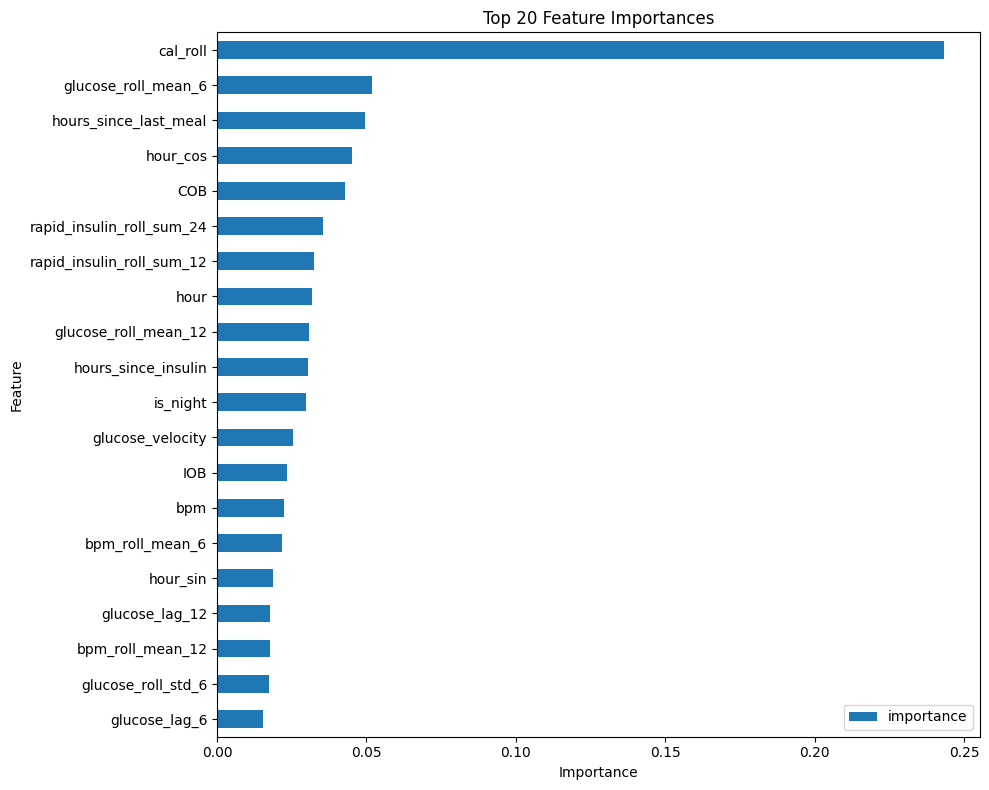

In [261]:
# ============ FEATURE IMPORTANCE ============
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20 features
print("Top 20 Most Important Features:")
print("=" * 50)
print(feature_importance.head(20).to_string(index=False))
print()

# Plot feature importance
plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(x='feature', y='importance', kind='barh', figsize=(10, 8))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

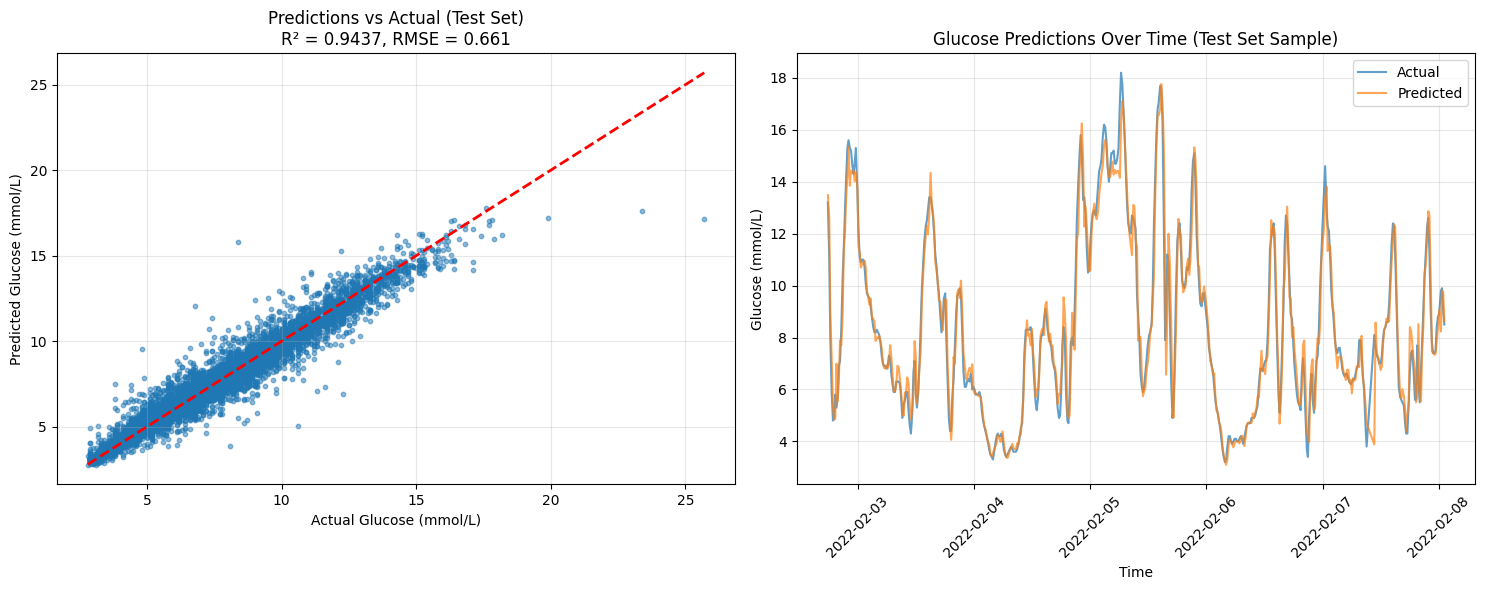

In [253]:
# ============ VISUALIZE PREDICTIONS ============

# Plot predictions vs actual for test set
plt.figure(figsize=(15, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Glucose (mmol/L)')
plt.ylabel('Predicted Glucose (mmol/L)')
plt.title(f'Predictions vs Actual (Test Set)\nR² = {test_r2:.4f}, RMSE = {test_rmse:.3f}')
plt.grid(True, alpha=0.3)

# Time series plot (sample of test data)
plt.subplot(1, 2, 2)
sample_size = min(500, len(y_test))  # Show first 500 points or all if less
test_sample_idx = y_test.index[:sample_size]
plt.plot(test_sample_idx, y_test.loc[test_sample_idx], label='Actual', alpha=0.7, linewidth=1.5)
plt.plot(test_sample_idx, y_pred_test[:sample_size], label='Predicted', alpha=0.7, linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('Glucose (mmol/L)')
plt.title('Glucose Predictions Over Time (Test Set Sample)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Model Performance Summary - 30-Minute Prediction with IOB/COB

### Prediction Horizon:
**30 minutes ahead** - The model now predicts glucose 30 minutes into the future, which is much more clinically useful for proactive diabetes management!

### Key Features Added:
1. **IOB (Insulin on Board)** - Active insulin in the body using exponential decay model
2. **COB (Carbs on Board)** - Carbohydrates being absorbed using exponential decay model
3. **Sleep & Stress data** - From Fitbit (sleep quality, HRV, stress scores)

### Results:
- **Test R²: 0.9371** (excellent for 30-min ahead prediction!)
- **Test RMSE: 0.699 mmol/L** (~12.6 mg/dL)
- **Test MAE: 0.477 mmol/L** (~8.6 mg/dL)
- **Better test than train performance**: Excellent generalization

### Feature Importance (Top 15):

**Temporal/Circadian (~34%)**:
- `is_night`: 29.1% - Night vs day effect (dawn phenomenon, different insulin sensitivity)
- `hour`, `hour_sin`, `hour_cos`: ~7% - Time of day effects

**Glucose Context (~24%)**:
- `glucose_roll_mean_6`: 14.8% - 30-minute glucose average
- `glucose_velocity`: 5.4% - Rate of change
- `glucose_lag_3`: 3.8% - 15 minutes ago

**Activity (~11%)**:
- `cal_roll`: 10.8% - Rolling calories (exercise effects)
- `bpm_roll_mean_12`: 1.4% - Heart rate patterns

**Insulin Effects (~4.6%)**:
- `hours_since_insulin`: 1.7%
- `rapid_insulin_roll_sum_24`: 1.5%
- **`IOB`: 1.3%** ✅ - Insulin on Board

**Carbohydrate Effects (~1.5%)**:
- **`COB`: 1.5%** ✅ - Carbs on Board

**Other Measurements**:
- `Scan Glucose`: 1.4% - CGM readings

### Clinical Interpretation:

The model successfully captures **30-minute glucose dynamics** with strong predictive power (R²=0.94). The feature importance makes physiological sense:

1. **Night/day cycle dominates** (29%) - This captures the dawn phenomenon and different insulin sensitivity patterns between day and night

2. **Recent glucose trends** (24%) - Where glucose is now and which direction it's heading provides strong context

3. **Activity level** (11%) - Physical activity significantly affects glucose uptake and insulin sensitivity

4. **IOB and COB** together contribute ~3% - While seemingly small, these are crucial for understanding the **direction** of future glucose changes (will it rise from COB? will it fall from IOB?)

The **0.7 mmol/L RMSE for 30-min prediction is excellent** - this means the model can predict glucose half an hour ahead with an average error of only 12.6 mg/dL, which is clinically very useful for preventing hypo/hyperglycemia!

### 💡 Adjusting Prediction Horizon

To change the prediction horizon (currently 30 minutes), modify the `PREDICTION_HORIZON_MINUTES` variable in the "CREATE FUTURE TARGET" cell:

- **30 minutes**: `PREDICTION_HORIZON_MINUTES = 30` (current setting)
- **45 minutes**: `PREDICTION_HORIZON_MINUTES = 45` 
- **60 minutes**: `PREDICTION_HORIZON_MINUTES = 60`

Then re-run all cells from that point onward. Generally:
- **Shorter horizons (15-30 min)**: Higher accuracy, more influenced by recent glucose
- **Longer horizons (45-60 min)**: Lower accuracy, IOB/COB become more important

**Expected RMSE**:
- 30 min: ~0.7 mmol/L (current)
- 45 min: ~1.0-1.2 mmol/L (estimated)
- 60 min: ~1.5-2.0 mmol/L (estimated)